### **Initialization**

In [10]:
import random
import numpy as np
import random
import statistics
import heapq
import matplotlib.pyplot as plt
from scipy import stats

### **Queue** <br>
A queue Q is a data structure where elements are added at the back and removed at the front. <br>
Supported operations:
- Enqueue(x): add x to Q.<br>
- Dequeue(): remove and return the *first added* element in Q.<br>
- IsEmpty(): return True if Q is empty.<br><br>
All operations in O(1) time. Space is O(N). <br>
(This implementation uses a singly linked list)

In [2]:
class Node():
    def __init__(self, value):
        self.value = value
        self.next = None
        self.prev = None

class Queue():
    def __init__(self):
        self.size = 0
        self.front = None
        self.end = None
        self.queue = []
    
    def enqueue(self, x):
        node = Node(x)
        if self.end == None:
            self.front = node
            self.end = node
            self.size += 1
            self.queue.append(node.value)
            return
        
        # Inserting at the end of the queue
        if x >= self.end.value:
            node.prev = self.end
            self.end.next = node
            self.end = node
            self.queue.append(node.value)
            self.size += 1
        
        # Inserting an event with a timestamp that is less than the end of the queue
        current = self.front
        index = 0
        while current is not None:
            if x < current.value:
                node.next = current
                node.prev = current.prev

                if current.prev:
                    current.prev.next = node
                else:
                    self.front = node

                current.prev = node
                self.queue.insert(index, node.value)
                self.size += 1
                return

            current = current.next
            index += 1
        
        #print("Size of queue: ", self.size)
    
    def dequeue(self):
        if self.is_empty():
            raise Exception("Dequeueing from an empty queue")
        remove = self.front
        self.front = self.front.next
        self.size -= 1
        self.queue.remove(remove.value)
        if self.front == None:
            self.end = None
        else:
            self.front.prev = None 
        return remove.value

    def is_empty(self):
        return self.size == 0

### **Defining the simulation**

In [3]:
# Simulation executive
def random_number_generator(rate):
    return random.expovariate(rate) # waiting time between events of poisson distribution are exponentially distributed

In [4]:
def simulation_func(seed_value, simulation_time, lam, mu):

    # Initialization routine
    clock = 0.0
    arrival_queue = Queue()
    departure_queue = Queue()
    server_occupied = False
    all_arrival_times = []
    all_departure_times = []
    num_packages_in_system = 0
    num_in_queue = 0
    num_served = 0
    last_event_time = 0.0

    # Statistical counters
    area_num_in_queue = 0.0
    area_num_in_system = 0.0
    area_server_status = 0.0

    # Setting seed for reproducibility
    random.seed(seed_value)

    arrival_queue.enqueue(random_number_generator(lam)) # Schedule the first arrival at time 0
    departure_queue.enqueue(float('inf')) # No departure scheduled at the beginning

    while clock < simulation_time:
        last_event_time = clock

        if arrival_queue.front.value <= departure_queue.front.value:
            # Timing routine
            first_in_queue = arrival_queue.front.value
            clock = first_in_queue 

            # Statistical Counters Computation
            area_num_in_queue += num_in_queue * (clock - last_event_time)
            area_num_in_system += (num_in_queue + (1 if server_occupied else 0)) * (clock - last_event_time)
            area_server_status += (1 if server_occupied else 0) * (clock - last_event_time)

            # Pop the event from the arrival queue
            arrival_queue.dequeue()
        
            if server_occupied == False:
                server_occupied = True

                # Next departure
                next_departure_time = clock + random_number_generator(mu) 
                departure_queue.enqueue(next_departure_time)

            else:
                num_in_queue += 1
                #print("Number in queue: ", num_in_queue)

            # Next arrival
            next_arrival_time = clock + random_number_generator(lam) 
            arrival_queue.enqueue(next_arrival_time)
            all_arrival_times.append(clock)
            
        else:
            # Timing routine
            first_in_queue = departure_queue.front.value
            clock = first_in_queue 
            #print("Departure event time: ", clock)

            # Statistical Counters Computation
            area_num_in_queue += num_in_queue * (clock - last_event_time)
            area_num_in_system += (num_in_queue + (1 if server_occupied else 0)) * (clock - last_event_time)
            area_server_status += (1 if server_occupied else 0) * (clock - last_event_time)
            
            # Pop the event from the queue
            departure_queue.dequeue()
            num_served += 1
            all_departure_times.append(clock)
            
            if num_in_queue > 0:
                num_in_queue -= 1
                next_departure_time = clock + random_number_generator(mu)
                departure_queue.enqueue(next_departure_time)
                server_occupied = True
            else:
                server_occupied = False
                #departure_queue.enqueue(float("inf")) # Ensuring that departure queue is never empty
    
    return all_arrival_times, all_departure_times, area_num_in_queue, area_num_in_system, area_server_status, num_served

### Independent Replicates

In [ ]:
def independent_replicates(b, lambda_value, mu_value, simulation_time_value = 20000):

    seed_list = [random.randint(0, 1000000) for _ in range(b)]

    sample_means = []
    sample_variances = []

    arrival_time_pr_sim = []
    departure_time_pr_sim = []

    for seed_v in seed_list:
        arrival, departure, *_ = simulation_func(
            seed_value=seed_v,
            simulation_time=simulation_time_value,
            lam=lambda_value,
            mu=mu_value
        )

        diff = [d - a for d, a in zip(departure, arrival)]

        mean_diff = mean_diff = statistics.mean(diff)
        var_diff = statistics.variance(diff)

        sample_means.append(mean_diff)
        sample_variances.append(var_diff)

        arrival_time_pr_sim.append(arrival)
        departure_time_pr_sim.append(departure)

    return arrival_time_pr_sim, departure_time_pr_sim

In [19]:
lambda_value = 2
mu_value = 3
b = 10
arrival_time_pr_sim, departure_time_pr_sim = independent_replicates(b=10, lambda_value=lambda_value, mu_value=mu_value, simulation_time_value = 20000)


In [26]:
def mean_replicates(arrival_time_pr_sim, departure_time_pr_sim):

    diff_pr_sim = [
        [d - a for d, a in zip(dep, arr)]
        for arr, dep in zip(arrival_time_pr_sim, departure_time_pr_sim)
    ]

    def running_average(arr):
        return np.cumsum(arr) / np.arange(1, len(arr) + 1)

    ra_sims = [running_average(np.array(sim)) for sim in diff_pr_sim]

    # Common time grid from max start to min end across all simulations
    t_start = max(arr[0] for arr in arrival_time_pr_sim)
    t_end   = min(arr[-1] for arr in arrival_time_pr_sim)
    common_grid = np.linspace(t_start, t_end, 2000)

    # Interpolate each simulation onto the common time grid
    interpolated = np.stack([
        np.interp(common_grid, arrival_time_pr_sim[i][:len(ra_sims[i])], ra_sims[i])
        for i in range(b)
    ], axis=0)

    mean_curve = np.mean(interpolated, axis=0)

    return mean_curve, common_grid

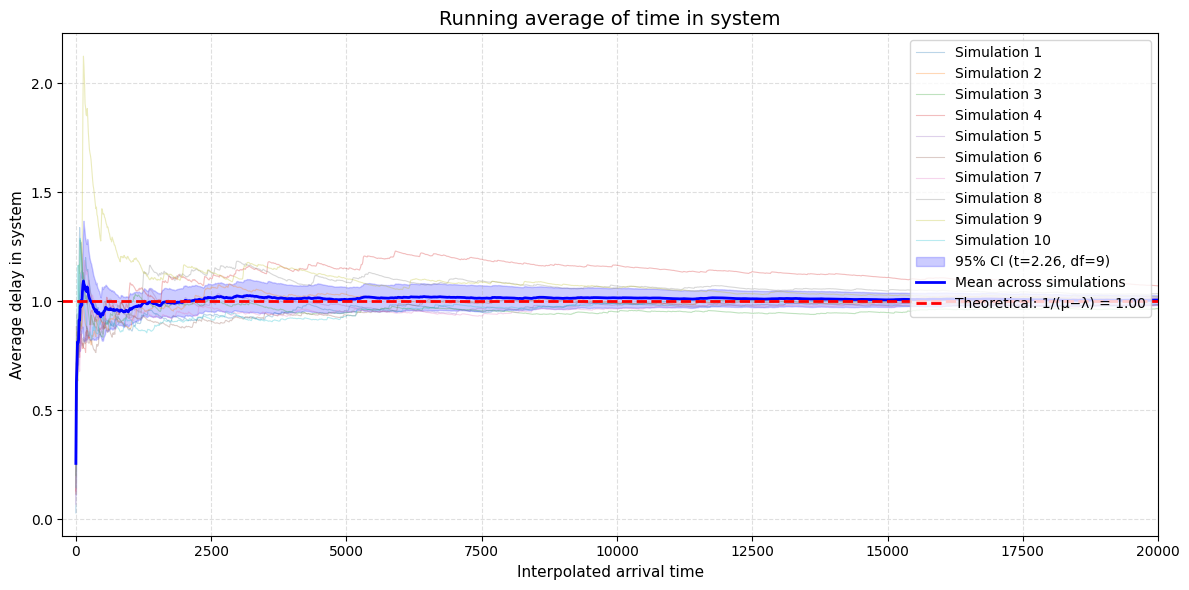

In [17]:
theoretical_average = 1 / (mu_value - lambda_value)

diff_pr_sim = [
    [d - a for d, a in zip(dep, arr)]
    for arr, dep in zip(arrival_time_pr_sim, departure_time_pr_sim)
]

def running_average(arr):
    return np.cumsum(arr) / np.arange(1, len(arr) + 1)

ra_sims = [running_average(np.array(sim)) for sim in diff_pr_sim]

# Common time grid from max start to min end across all simulations
t_start = max(arr[0] for arr in arrival_time_pr_sim)
t_end   = min(arr[-1] for arr in arrival_time_pr_sim)
common_grid = np.linspace(t_start, t_end, 2000)

# Interpolate each simulation onto the common time grid
interpolated = np.stack([
    np.interp(common_grid, arrival_time_pr_sim[i][:len(ra_sims[i])], ra_sims[i])
    for i in range(b)
], axis=0)

mean_curve = np.mean(interpolated, axis=0)
std_dev    = np.std(interpolated, axis=0, ddof=1)
t_crit     = stats.t.ppf(0.975, df=b-1)
ci_upper   = mean_curve + t_crit * std_dev / np.sqrt(b)
ci_lower   = mean_curve - t_crit * std_dev / np.sqrt(b)

fig, ax = plt.subplots(figsize=(12, 6))

# Individual simulations
for i in range(b):
    ax.plot(common_grid, interpolated[i], linewidth=0.8, alpha=0.3, label=f"Simulation {i+1}")

# CI and mean on the common grid
ax.fill_between(common_grid, ci_lower, ci_upper, color='blue', alpha=0.2, label=f"95% CI (t={t_crit:.2f}, df={b-1})")
ax.plot(common_grid, mean_curve, color='blue', linewidth=2, label="Mean across simulations")

ax.axhline(y=theoretical_average, linestyle='--', linewidth=2, color='red', label=f"Theoretical: 1/(µ−λ) = {theoretical_average:.2f}")

ax.set_title("Running average of time in system", fontsize=14)
ax.set_xlabel("Interpolated arrival time", fontsize=11)
ax.set_ylabel("Average delay in system", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper right')
ax.set_xlim(-250, 20000)
plt.tight_layout()
plt.show()

### Convergence time
We define the convergence time as the first time when the running average enters a tolerance band around the theoretical value and stays inside it.
$$
\left| \hat{T}(t) - \mathbb{E}[T] \right| \le \varepsilon \cdot \mathbb{E}[T], \quad \forall t \ge t_c
$$

In [31]:
def convergence_time(arrival_times, running_avg, theoretical_value, epsilon=0.05, K=100):
    running_avg = np.asarray(running_avg)

    tol = epsilon * theoretical_value # compute tolerance threshold
    n = len(running_avg)
    
    for i in range(n-K): # for each convergence window
        window = running_avg[i:i+K]
        if np.all(np.abs(window - theoretical_value) <= tol):
            return arrival_times[i]
    return float('inf') # no convergence

In [32]:
convergence_times = []
for i in range(b):
    conv_time = convergence_time(arrival_time_pr_sim[i], ra_sims[i], theoretical_value=theoretical_average)
    convergence_times.append(conv_time)

print(convergence_times)

[272.5257653665259, 1150.6652152932825, 173.8559032596051, 562.2082772174924, 281.59795139056973]


### Changing $\lambda$ and $\mu$ values

In [38]:
# Changing mu and lamdba values

mu = 10

rho_list = np.array([
    0.20, 0.30, 0.40, 0.50, 0.60,
    0.70, 0.75, 0.80, 0.85,
    0.88, 0.90, 0.92, 0.94, 0.95
])

lambda_list = rho_list * mu
mu_list = np.ones_like(lambda_list) * mu

convergence_times = []

for lam, mu_value in zip(lambda_list, mu_list):
    theoretical = 1 / (mu_value - lam)
    arrival_time_pr_sim, departure_time_pr_sim = independent_replicates(b=50, lambda_value=lam, mu_value=mu_value, simulation_time_value = 10000)
    
    mean_curve, common_grid = mean_replicates(arrival_time_pr_sim, departure_time_pr_sim)

    conv_time = convergence_time(common_grid, mean_curve, theoretical_value=theoretical)
    print(f"Lambda: {lam}, Mu: {mu_value}, Convergence Time: {conv_time:.2f}")
    convergence_times.append(conv_time)

Lambda: 2.0, Mu: 10.0, Convergence Time: 636.56
Lambda: 3.0, Mu: 10.0, Convergence Time: 96.73
Lambda: 4.0, Mu: 10.0, Convergence Time: 106.22
Lambda: 5.0, Mu: 10.0, Convergence Time: 611.04
Lambda: 6.0, Mu: 10.0, Convergence Time: 215.75
Lambda: 7.0, Mu: 10.0, Convergence Time: 120.42
Lambda: 7.5, Mu: 10.0, Convergence Time: 1205.99
Lambda: 8.0, Mu: 10.0, Convergence Time: 365.49
Lambda: 8.5, Mu: 10.0, Convergence Time: 1125.99
Lambda: 8.8, Mu: 10.0, Convergence Time: 1621.03
Lambda: 9.0, Mu: 10.0, Convergence Time: 4347.31
Lambda: 9.200000000000001, Mu: 10.0, Convergence Time: 2661.64
Lambda: 9.399999999999999, Mu: 10.0, Convergence Time: 1361.13
Lambda: 9.5, Mu: 10.0, Convergence Time: 2206.45


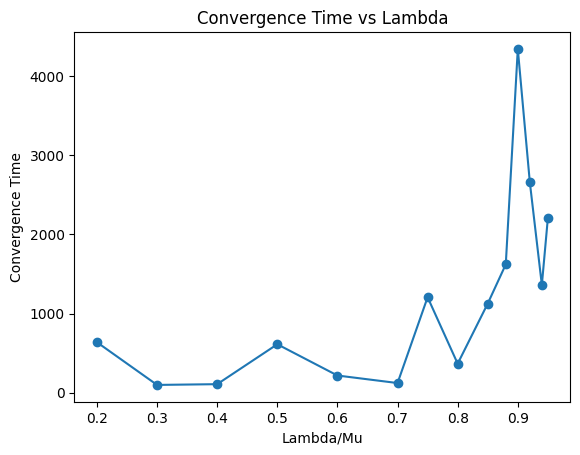

In [39]:
rho = np.array(lambda_list) / np.array(mu_list)
plt.plot(rho, convergence_times, marker='o')
plt.xlabel('Lambda/Mu')
plt.ylabel('Convergence Time')
plt.title('Convergence Time vs Lambda')
plt.show()